# Sentiment Analysis on Sample Client Feedback



## 1) Installing and importing the dependencies

In [2]:
!pip install vaderSentiment --quiet --break-system-packages

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

## 2) Sample client feedback dataset



In [3]:
feedback_comments = [
    "The product quality exceeded my expectations, I will definitely order again!",
    "Customer support was rude and took forever to respond to my ticket.",
    "Delivery was on time and the packaging was neat.",
    "I'm not sure how I feel about the new update, it's just okay I guess.",
    "Absolutely love the new features, this is a game changer for our team!",
    "The app keeps crashing every time I try to upload a file, very frustrating.",
    "Pricing is fair for the value we get, no complaints here.",
    "Worst experience ever, I want a refund immediately.",
    "The interface is clean and easy to navigate, great job on the redesign.",
    "It works fine, nothing special but does the job.",
    "Your team went above and beyond to fix our issue, truly impressed!",
    "I had to wait three weeks for a simple replacement part, unacceptable.",
    "The onboarding process was smooth and well explained.",
    "Meh, it's an average product, similar to competitors.",
    "This is by far the best customer service I've received in years.",
    "The billing system charged me twice and nobody has resolved it yet.",
    "Solid product overall, though the mobile app could use some polish.",
    "I appreciate the quick turnaround on my support request, thank you!",
    "The instructions were confusing and the setup took way longer than it should.",
    "Great value for money, would recommend to a friend.",
    "Terrible experience, the product broke after just two days of use.",
    "It's decent, does what it promises but nothing extraordinary.",
    "Fantastic! The new dashboard makes tracking everything so much easier.",
    "Very disappointed with the lack of communication during the delay.",
    "Support agent was knowledgeable and resolved my issue in minutes.",
    "The product is okay, but shipping fees are a bit too high.",
    "Horrible customer service, I was put on hold for over an hour.",
]

print(f"Total feedback comments: {len(feedback_comments)}")

Total feedback comments: 27


## 3) Apply sentiment analysis using VADER



In [4]:
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return "Positive"
    elif compound_score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

rows = []
for comment in feedback_comments:
    scores = analyzer.polarity_scores(comment)
    rows.append({
        "comment": comment,
        "negative_score": scores["neg"],
        "neutral_score": scores["neu"],
        "positive_score": scores["pos"],
        "compound_score": scores["compound"],
        "sentiment": classify_sentiment(scores["compound"])
    })

df = pd.DataFrame(rows)
df

,comment,negative_score,neutral_score,positive_score,compound_score,sentiment
0,"The product quality exceeded my expectations, ...",0.000,0.770,0.230,0.4574,Positive
1,Customer support was rude and took forever to ...,0.191,0.637,0.172,-0.0772,Negative
2,Delivery was on time and the packaging was neat.,0.000,0.727,0.273,0.4588,Positive
3,"I'm not sure how I feel about the new update, ...",0.116,0.771,0.113,-0.0160,Neutral
4,"Absolutely love the new features, this is a ga...",0.000,0.715,0.285,0.6989,Positive
5,The app keeps crashing every time I try to upl...,0.197,0.803,0.000,-0.4927,Negative
6,"Pricing is fair for the value we get, no compl...",0.000,0.535,0.465,0.7147,Positive
7,"Worst experience ever, I want a refund immedia...",0.360,0.526,0.114,-0.5859,Negative
8,"The interface is clean and easy to navigate, g...",0.000,0.508,0.492,0.8658,Positive
9,"It works fine, nothing special but does the job.",0.162,0.698,0.140,-0.0590,Negative


## 4) Summarizing the distribution with a chart

In [5]:
sentiment_counts = df["sentiment"].value_counts().reindex(["Positive", "Neutral", "Negative"], fill_value=0)

print(sentiment_counts)
print(f"\nTotal comments analyzed: {len(df)}")

sentiment
Positive    15
Neutral      2
Negative    10
Name: count, dtype: int64

Total comments analyzed: 27


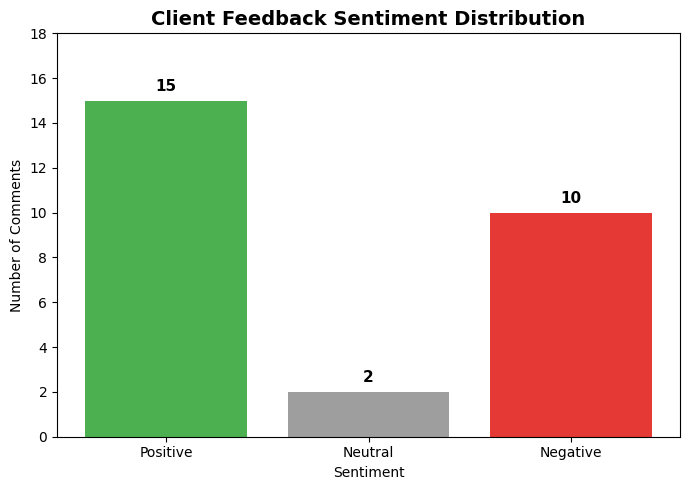

In [6]:
colors = {"Positive": "#4CAF50", "Neutral": "#9E9E9E", "Negative": "#E53935"}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(sentiment_counts.index, sentiment_counts.values,
               color=[colors[s] for s in sentiment_counts.index])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3, str(int(height)),
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Client Feedback Sentiment Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Comments")
ax.set_ylim(0, max(sentiment_counts.values) + 3)

plt.tight_layout()
plt.savefig("sentiment_distribution_chart.png", dpi=200)
plt.show()

## 5) Flagging the 3 most negative comments



In [7]:
most_negative = df.sort_values("compound_score").head(3).reset_index(drop=True)

print("TOP 3 MOST NEGATIVE COMMENTS FLAGGED FOR FOLLOW-UP:\n")
for i, row in most_negative.iterrows():
    print(f"{i+1}. [Compound score: {row['compound_score']}]")
    print(f"   \"{row['comment']}\"\n")

TOP 3 MOST NEGATIVE COMMENTS FLAGGED FOR FOLLOW-UP:

1. [Compound score: -0.7902]
   "Very disappointed with the lack of communication during the delay."

2. [Compound score: -0.7096]
   "Terrible experience, the product broke after just two days of use."

3. [Compound score: -0.5859]
   "Worst experience ever, I want a refund immediately."



## 6) Exporting the results



In [8]:
df.to_csv("sentiment_analysis_results.csv", index=False)
most_negative.to_csv("flagged_negative_comments.csv", index=False)
print("Saved: sentiment_analysis_results.csv, flagged_negative_comments.csv, sentiment_distribution_chart.png")

Saved: sentiment_analysis_results.csv, flagged_negative_comments.csv, sentiment_distribution_chart.png
